# Insurance Risk Analytics - Exploratory Data Analysis

## Project Overview

This project focuses on insurance risk analytics using historical insurance transaction data. The goal is to identify low-risk customer segments, analyze claim behavior, and generate business insights that can support pricing optimization and profitability improvement.



In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

# Data Loading

The dataset is loaded from the local data directory for analysis.

In [33]:
data_path = Path("../data/MachineLearningRating_v3.txt")

df = pd.read_csv(data_path, sep="|")

C:\Users\nbe\AppData\Local\Temp\ipykernel_19404\683810038.py:3: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path, sep="|")


In [34]:
df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


# Dataset Overview

This section provides an overview of the dataset structure, dimensions, and variable types.

In [35]:
df.shape

(1000098, 52)

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  str    
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  str    
 5   LegalType                 1000098 non-null  str    
 6   Title                     1000098 non-null  str    
 7   Language                  1000098 non-null  str    
 8   Bank                      854137 non-null   str    
 9   AccountType               959866 non-null   str    
 10  MaritalStatus             991839 non-null   str    
 11  Gender                    990562 non-null   str    
 12  Country                   1000098 non-null  str    
 13  Province                  1000098 non-

In [38]:
df.columns

Index(['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth',
       'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode',
       'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders',
       'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors',
       'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff',
       'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet',
       'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm',
       'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section',
       'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium',
       'TotalClaims'],
      dtype='str')

In [37]:
df.describe(include="all")

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1000098,1000098,1000098,1000098,1000098,1000098,854137,959866,991839,990562,1000098,1000098,1.000098e+06,1000098,1000098,1000098,9.995460e+05,999546,1.000098e+06,999546,999546,999546.000000,999546.000000,999546.000000,999546,999546.000000,999546,2.204560e+05,1000098,1000098,1000096.0,846803,358197,358197,358197,698,0.0,1.000098e+06,1000098,1.000098e+06,1000098,1000098,1000098,1000098,1000098,1000098,1000098,1000098,1.000098e+06,1.000098e+06
unique,NaN,NaN,23,2,4,6,5,1,11,3,3,3,1,9,NaN,16,45,1,NaN,5,NaN,46,411,NaN,NaN,NaN,13,NaN,174,NaN,2,2,1011.0,2,2,2,2,1,NaN,NaN,2,NaN,13,28,22,14,5,4,1,1,NaN,NaN
top,NaN,NaN,2015-08-01 00:00:00,False,,Individual,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,NaN,Transvaal (all except Pretoria),Johannesburg,Mobility - Motor,NaN,Passenger Vehicle,NaN,TOYOTA,QUANTUM 2.7 SESFIKILE 16s,NaN,NaN,NaN,B/S,NaN,4/2012,NaN,Yes,No,0.0,More than 6 months,No,No,No,No,NaN,NaN,Monthly,NaN,No excess,Passenger Liability,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,NaN,NaN
freq,NaN,NaN,106747,995075,895210,911929,933555,1000098,260811,597938,986208,940990,1000098,393865,NaN,296187,176020,1000098,NaN,933598,NaN,813280,186087,NaN,NaN,NaN,844400,NaN,287638,NaN,999861,656617,665918.0,845223,358165,358165,358110,698,NaN,NaN,999554,NaN,791235,104158,104183,824124,828125,915028,1000098,1000098,NaN,NaN
mean,1.048175e+05,7.956682e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.020601e+03,NaN,NaN,NaN,5.487770e+07,NaN,2.010225e+03,NaN,NaN,4.046642,2466.743258,97.207919,NaN,4.019250,NaN,2.255311e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.041727e+05,NaN,1.178757e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.190550e+01,6.486119e+01
std,6.329371e+04,5.290039e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.649854e+03,NaN,NaN,NaN,1.360381e+07,NaN,3.261391e+00,NaN,NaN,0.294020,442.800640,19.393256,NaN,0.468314,NaN,5.645157e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.508332e+06,NaN,3.997017e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.302845e+02,2.384075e+03
min,1.000000e+00,1.400000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN,NaN,4.041200e+06,NaN,1.987000e+03,NaN,NaN,0.000000,0.000000,0.000000,NaN,0.000000,NaN,2.000000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e-02,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.270000e+02,NaN,NaN,NaN,6.005692e+07,NaN,2.008000e+03,NaN,NaN,4.000000,2237.000000,75.000000,NaN,4.000000,NaN,1.350000e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e+03,NaN,3.224800e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000e+03,NaN,NaN,NaN,6.005842e+07,NaN,2.011000e+03,NaN,NaN,4.000000,2694.000000,111.000000,NaN,4.000000,NaN,2.200000e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.500000e+03,NaN,8.436900e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.180000e+03,NaN,NaN,NaN,6.005842e+07,NaN,2.013000e+03,NaN,NaN,4.000000,2694.000000,111.000000,NaN,4.000000,NaN,2.800000e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.50000

## Initial Observations

The dataset contains both numerical and categorical variables related to insurance transactions, customer demographics, vehicle information, and claim behavior.

The dataset appears suitable for:

- Risk segmentation
- Premium analysis
- Claim severity analysis
- Geographic comparisons
- Temporal trend analysis

# Data Type Analysis

In [7]:
df.dtypes

UnderwrittenCoverID           int64
PolicyID                      int64
TransactionMonth                str
IsVATRegistered                bool
Citizenship                     str
LegalType                       str
Title                           str
Language                        str
Bank                            str
AccountType                     str
MaritalStatus                   str
Gender                          str
Country                         str
Province                        str
PostalCode                    int64
MainCrestaZone                  str
SubCrestaZone                   str
ItemType                        str
mmcode                      float64
VehicleType                     str
RegistrationYear              int64
make                            str
Model                           str
Cylinders                   float64
cubiccapacity               float64
kilowatts                   float64
bodytype                        str
NumberOfDoors               

In [40]:
numerical_cols = df.select_dtypes(include=np.number).columns

categorical_cols = df.select_dtypes(include="object").columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['UnderwrittenCoverID', 'PolicyID', 'PostalCode', 'mmcode',
       'RegistrationYear', 'Cylinders', 'cubiccapacity', 'kilowatts',
       'NumberOfDoors', 'CustomValueEstimate', 'NumberOfVehiclesInFleet',
       'SumInsured', 'CalculatedPremiumPerTerm', 'TotalPremium',
       'TotalClaims'],
      dtype='str')

Categorical Columns:
Index(['TransactionMonth', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'VehicleType', 'make',
       'Model', 'bodytype', 'VehicleIntroDate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff',
       'Rebuilt', 'Converted', 'CrossBorder', 'TermFrequency',
       'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section',
       'Product', 'StatutoryClass', 'StatutoryRiskType'],
      dtype='str')


C:\Users\nbe\AppData\Local\Temp\ipykernel_19404\4129928474.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


# Missing Value Analysis

This section evaluates missing values across all variables to identify potential data quality issues.

In [8]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
CustomValueEstimate         779642
Rebuilt                     641901
Converted                   641901
WrittenOff                  641901
NewVehicle                  153295
Bank                        145961
AccountType                  40232
Gender                        9536
MaritalStatus                 8259
VehicleType                    552
make                           552
mmcode                         552
Model                          552
Cylinders                      552
bodytype                       552
kilowatts                      552
NumberOfDoors                  552
VehicleIntroDate               552
cubiccapacity                  552
CapitalOutstanding               2
dtype: int64

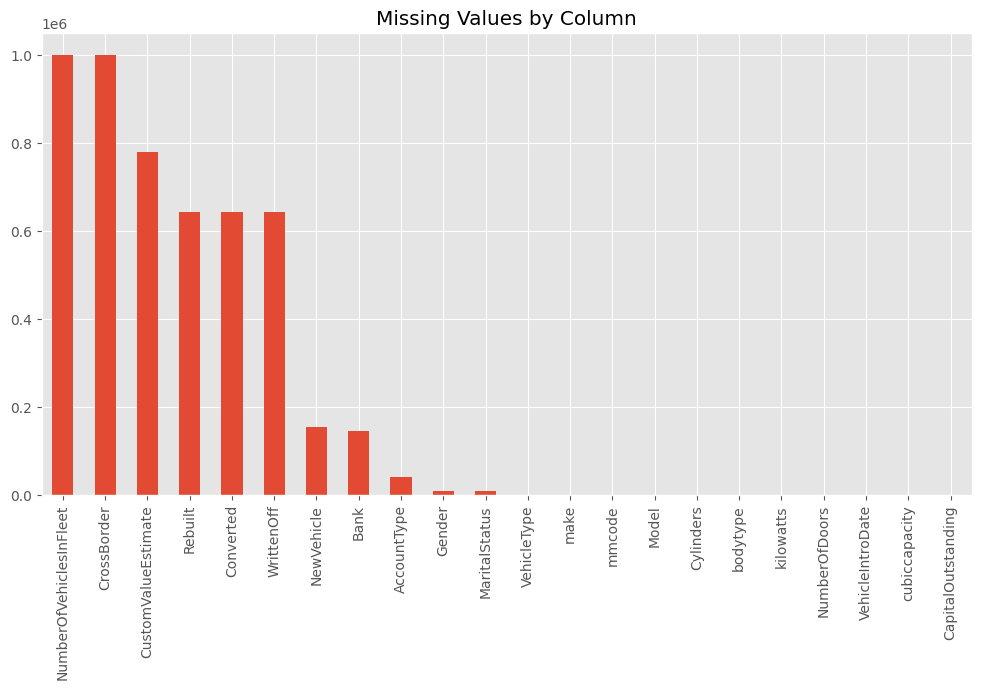

In [42]:
plt.figure(figsize=(12,6))
missing[missing > 0].plot(kind="bar")
plt.title("Missing Values by Column")
plt.show()

## Missing Value Insights

Columns with high missing values may require imputation or removal depending on business relevance and analytical importance.

Low levels of missingness can typically be handled through statistical imputation techniques.

# Duplicate Analysis

In [43]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns.tolist()

['UnderwrittenCoverID',
 'PolicyID',
 'TransactionMonth',
 'IsVATRegistered',
 'Citizenship',
 'LegalType',
 'Title',
 'Language',
 'Bank',
 'AccountType',
 'MaritalStatus',
 'Gender',
 'Country',
 'Province',
 'PostalCode',
 'MainCrestaZone',
 'SubCrestaZone',
 'ItemType',
 'mmcode',
 'VehicleType',
 'RegistrationYear',
 'make',
 'Model',
 'Cylinders',
 'cubiccapacity',
 'kilowatts',
 'bodytype',
 'NumberOfDoors',
 'VehicleIntroDate',
 'CustomValueEstimate',
 'AlarmImmobiliser',
 'TrackingDevice',
 'CapitalOutstanding',
 'NewVehicle',
 'WrittenOff',
 'Rebuilt',
 'Converted',
 'CrossBorder',
 'NumberOfVehiclesInFleet',
 'SumInsured',
 'TermFrequency',
 'CalculatedPremiumPerTerm',
 'ExcessSelected',
 'CoverCategory',
 'CoverType',
 'CoverGroup',
 'Section',
 'Product',
 'StatutoryClass',
 'StatutoryRiskType',
 'TotalPremium',
 'TotalClaims']

# Feature Engineering

This section creates additional business metrics required for insurance risk analysis.

In [77]:
df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]

df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

In [78]:
df[["LossRatio", "Margin"]].head()

,LossRatio,Margin
0,0.0,21.929825
1,0.0,21.929825
2,NaN,0.000000
3,0.0,512.848070
4,NaN,0.000000


# Univariate Analysis

This section analyzes the distributions of important numerical and categorical variables.

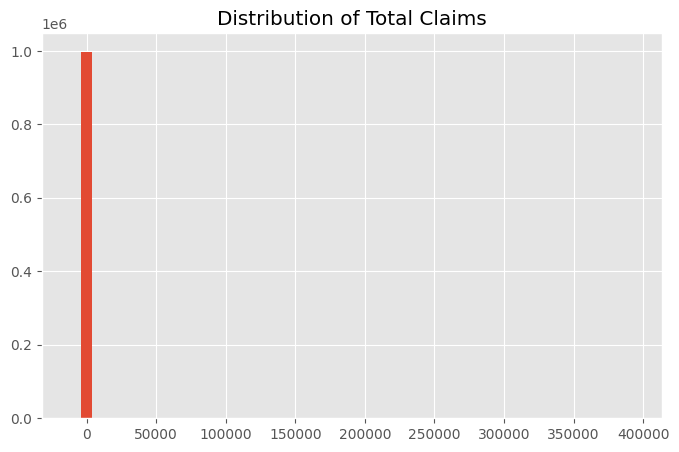

In [12]:
df["TotalClaims"].hist(bins=50, figsize=(8,5))
plt.title("Distribution of Total Claims")
plt.show()

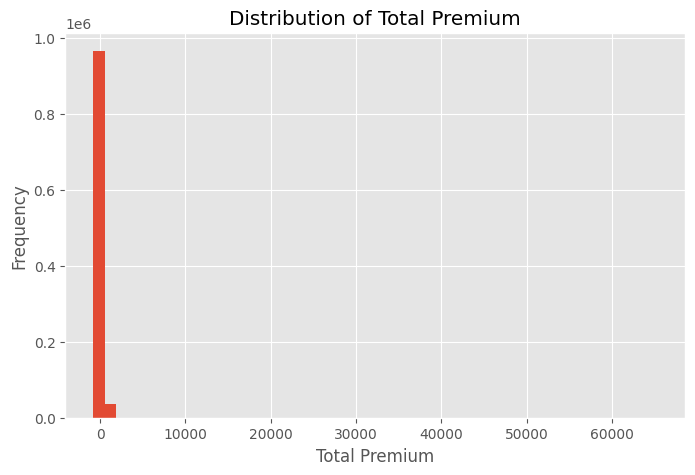

In [45]:
df["TotalPremium"].hist(bins=50, figsize=(8,5))

plt.title("Distribution of Total Premium")

plt.xlabel("Total Premium")

plt.ylabel("Frequency")

plt.show()

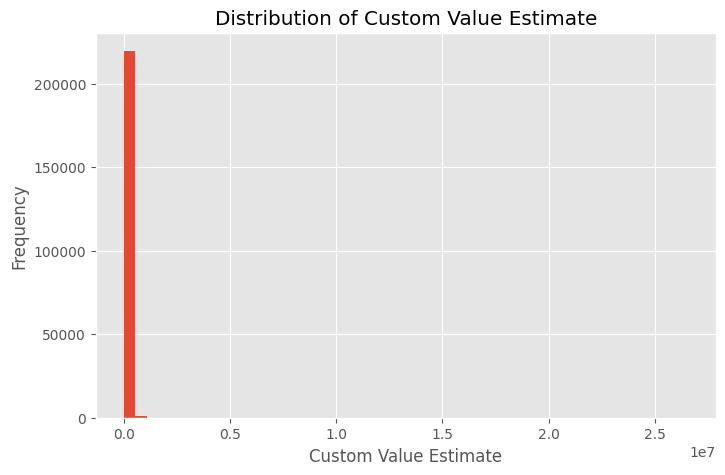

In [46]:
df["CustomValueEstimate"].hist(bins=50, figsize=(8,5))

plt.title("Distribution of Custom Value Estimate")

plt.xlabel("Custom Value Estimate")

plt.ylabel("Frequency")

plt.show()

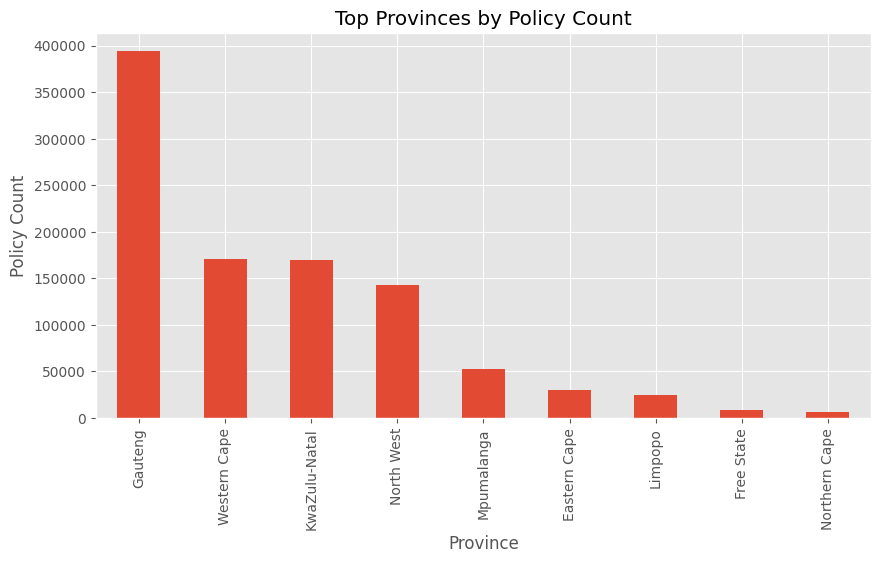

In [47]:
df["Province"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Provinces by Policy Count")

plt.xlabel("Province")

plt.ylabel("Policy Count")

plt.show()

## Univariate Analysis Insights

The distributions indicate that insurance claim-related variables are highly skewed, with several extreme values.

This suggests the presence of high-cost claims and potentially high-risk customer segments.

# Outlier Analysis

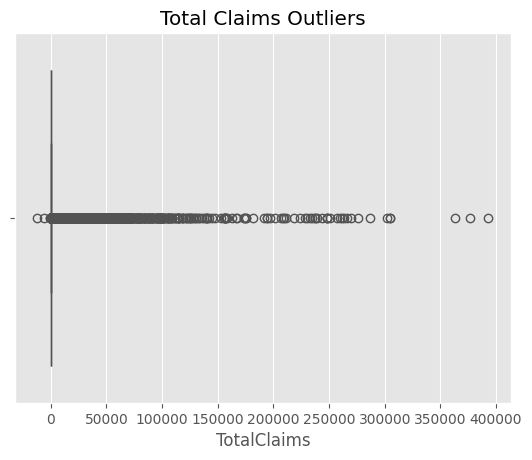

In [14]:
sns.boxplot(x=df["TotalClaims"])
plt.title("Total Claims Outliers")
plt.show()

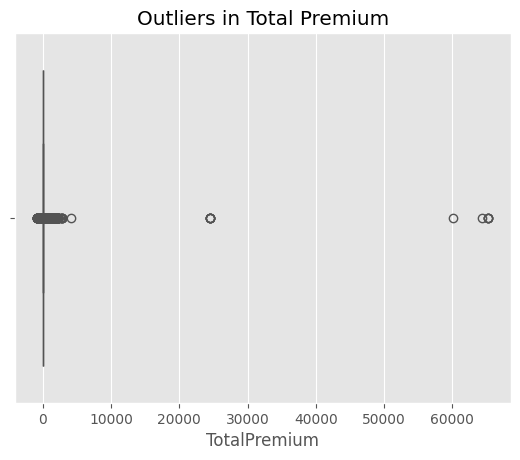

In [50]:
sns.boxplot(x=df["TotalPremium"])

plt.title("Outliers in Total Premium")

plt.show()

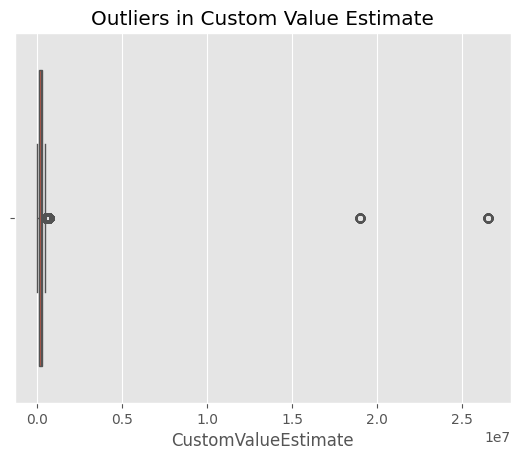

In [51]:
sns.boxplot(x=df["CustomValueEstimate"])

plt.title("Outliers in Custom Value Estimate")

plt.show()

## Outlier Insights

Several extreme outliers are visible in claims and premium distributions.

These observations may represent:
- high-value vehicles
- severe insurance claims
- unusual customer profiles

Outlier analysis is important because extreme claims significantly affect insurance profitability and pricing models.

# Bivariate and Multivariate Analysis

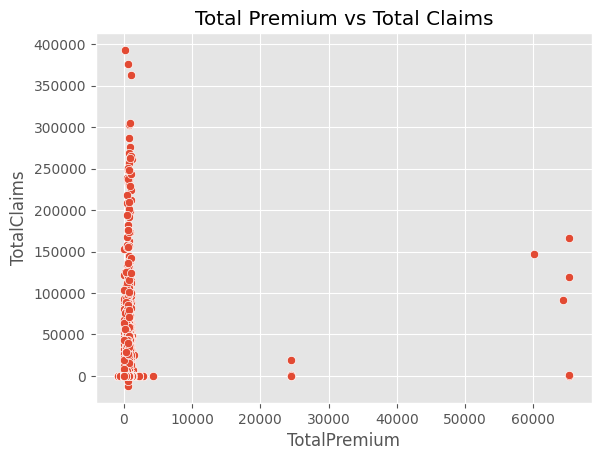

In [52]:
sns.scatterplot(
    data=df,
    x="TotalPremium",
    y="TotalClaims"
)
plt.title("Total Premium vs Total Claims")
plt.show()

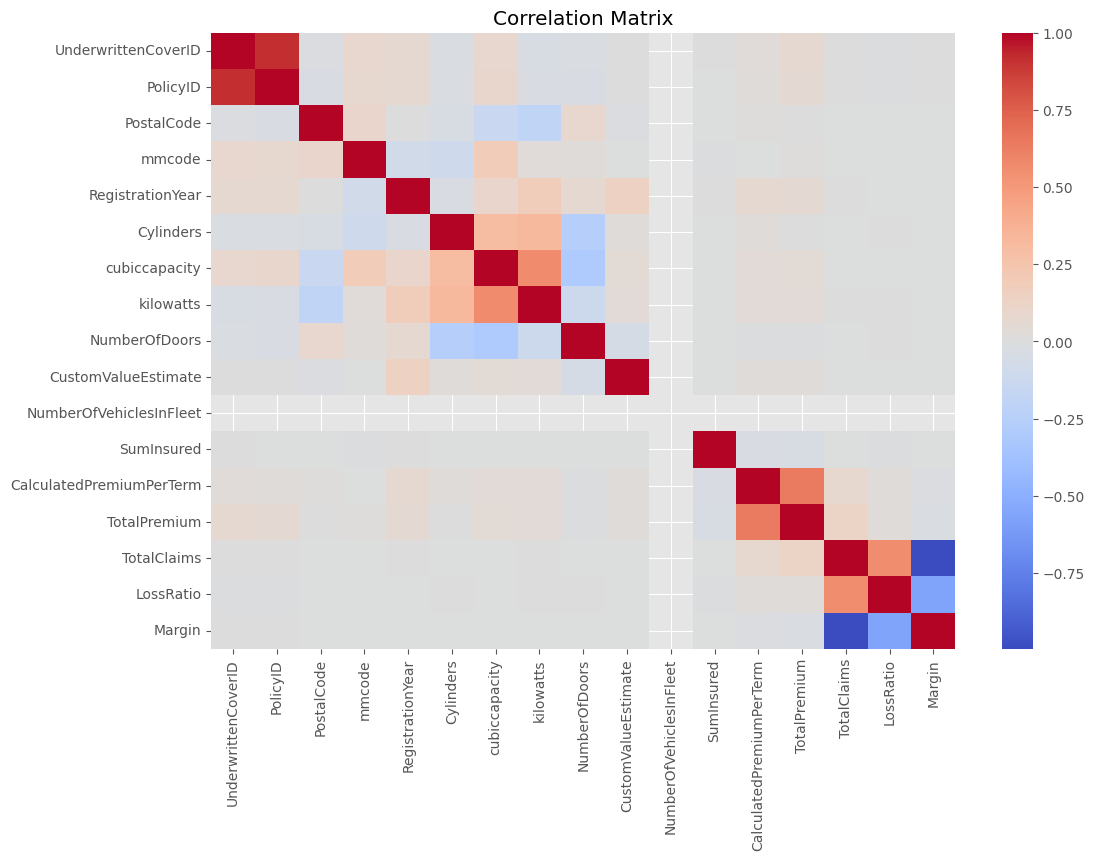

In [16]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Correlation Insights

The correlation matrix highlights relationships between financial and vehicle-related variables.

Strong correlations may indicate:
- potential predictive variables
- pricing relationships
- claim severity patterns

# Geographic Analysis

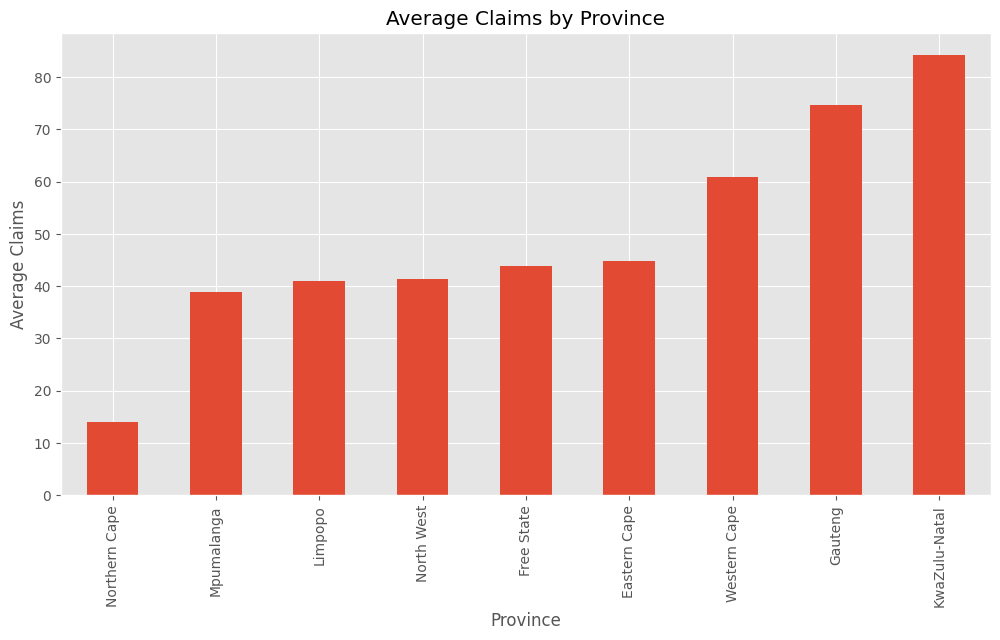

In [53]:
province_claims = (
    df.groupby("Province")["TotalClaims"]
    .mean()
    .sort_values()
)

province_claims.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Average Claims by Province")

plt.xlabel("Province")

plt.ylabel("Average Claims")

plt.show()

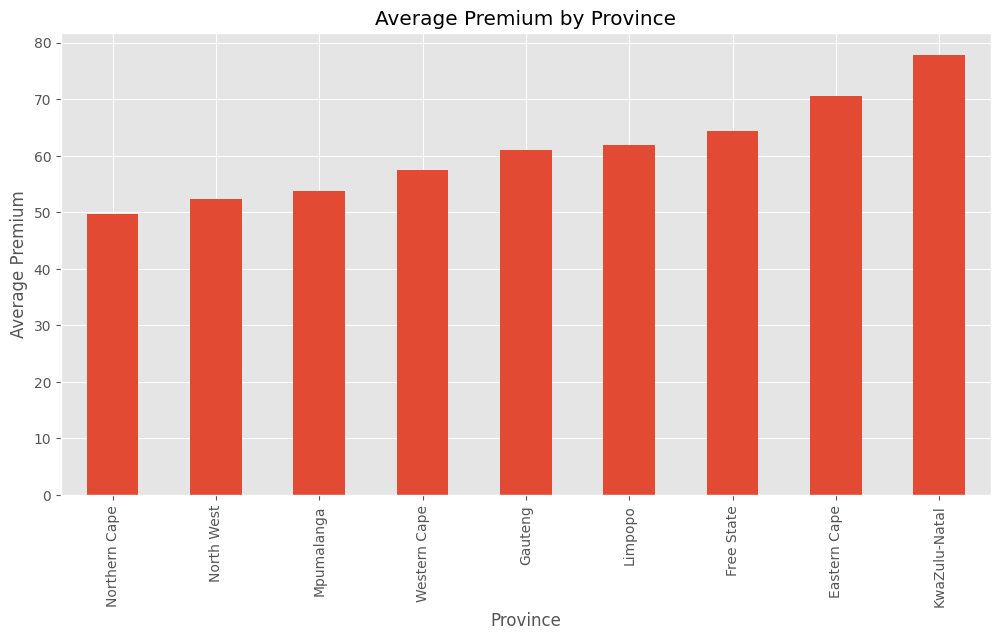

In [54]:
province_premium = (
    df.groupby("Province")["TotalPremium"]
    .mean()
    .sort_values()
)

province_premium.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Average Premium by Province")

plt.xlabel("Province")

plt.ylabel("Average Premium")

plt.show()

## Geographic Insights

Geographic differences in premiums and claims suggest regional variations in insurance risk.

Certain provinces may represent:
- higher accident frequency
- higher vehicle values
- greater insurance exposure

# Temporal Analysis

In [56]:
top_makes = (
    df.groupby("Province")["make"]
    .agg(lambda x: x.value_counts().index[0])
)

In [57]:
df["TransactionMonth"] = pd.to_datetime(df["TransactionMonth"])

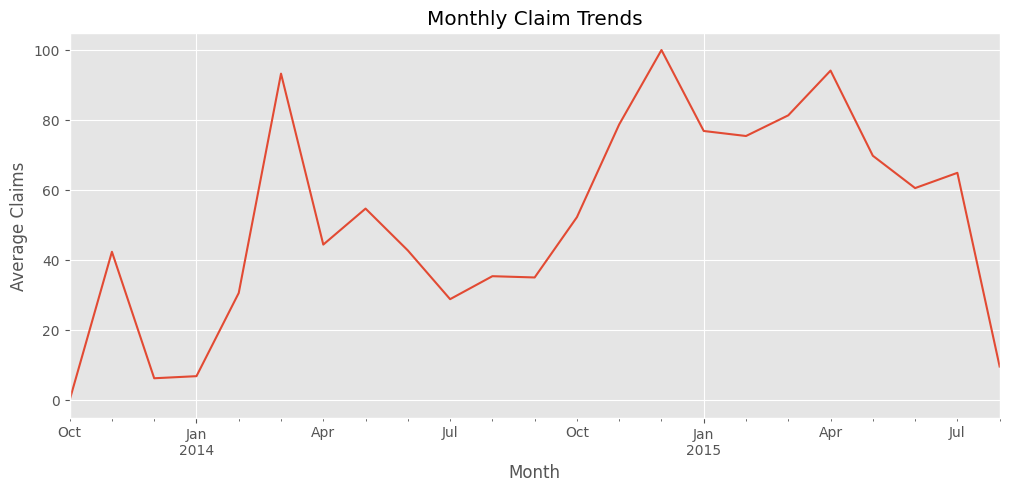

In [59]:
monthly_claims = (
    df.groupby(
        df["TransactionMonth"].dt.to_period("M")
    )["TotalClaims"]
    .mean()
)

monthly_claims.plot(figsize=(12,5))

plt.title("Monthly Claim Trends")

plt.xlabel("Month")

plt.ylabel("Average Claims")

plt.show()

## Temporal Insights

Temporal analysis helps identify:
- seasonal claim behavior
- trends in insurance risk
- changes in claim severity over time

These insights are valuable for forecasting and pricing optimization.

# Business Questions and Insights

In [74]:
overall_loss_ratio = (
    df["TotalClaims"].sum() /
    df["TotalPremium"].sum()
)

overall_loss_ratio

np.float64(1.0477452570332206)

In [76]:
df.columns

Index(['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth',
       'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode',
       'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders',
       'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors',
       'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff',
       'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet',
       'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm',
       'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section',
       'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium',
       'TotalClaims'],
      dtype='str')

In [79]:
province_loss_ratio = (
    df.groupby("Province")["LossRatio"]
    .mean()
    .sort_values()
)

province_loss_ratio

Province
Northern Cape    0.203831
Eastern Cape          inf
KwaZulu-Natal         inf
Free State            inf
Limpopo               inf
North West            inf
Western Cape          inf
Gauteng               NaN
Mpumalanga            NaN
Name: LossRatio, dtype: float64

In [80]:
vehicle_loss_ratio = (
    df.groupby("VehicleType")["LossRatio"]
    .mean()
    .sort_values()
)

vehicle_loss_ratio

VehicleType
Light Commercial     0.543917
Bus                       inf
Heavy Commercial          inf
Medium Commercial         inf
Passenger Vehicle         NaN
Name: LossRatio, dtype: float64

In [81]:
gender_loss_ratio = (
    df.groupby("Gender")["LossRatio"]
    .mean()
    .sort_values()
)

gender_loss_ratio

Gender
Female           inf
Male             inf
Not specified    NaN
Name: LossRatio, dtype: float64

In [68]:
df.groupby("make")["TotalClaims"].mean().sort_values()

make
CITROEN                                  0.000000
CHERY                                    0.000000
FORD                                     0.000000
DAIHATSU                                 0.000000
GEELY                                    0.000000
HINO                                     0.000000
HUMMER                                   0.000000
HONDA                                    0.000000
JINBEI                                   0.000000
KIA                                      0.000000
LEXUS                                    0.000000
MAHINDRA                                 0.000000
PROTON                                   0.000000
RENAULT                                  0.000000
PEUGEOT                                  0.000000
OPEL                                     0.000000
TATA                                     0.000000
VOLVO                                    0.000000
SCANIA                                   0.000000
FOTON                                    3.48

## Key Business Insights

### Overall Profitability
The overall loss ratio provides an estimate of overall insurance profitability.

### Regional Risk
Some provinces demonstrate significantly higher average claim costs and loss ratios.

### Vehicle Risk
Vehicle categories with higher loss ratios may require adjusted premium pricing strategies.

### Gender-Based Risk
Differences in loss ratios across gender categories may indicate behavioral or demographic risk patterns.

### Outlier Impact
Extreme claims can significantly affect profitability and must be carefully analyzed in pricing models.

# Conclusion

The exploratory data analysis identified important patterns related to insurance claims, premiums, geography, and customer risk profiles.

Key findings include:
- highly skewed claim distributions
- significant regional variation
- presence of extreme outliers
- meaningful profitability differences across customer segments

These findings provide a strong foundation for:
- hypothesis testing
- predictive modeling
- pricing optimization
- customer risk segmentation